In [2]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import printPolts

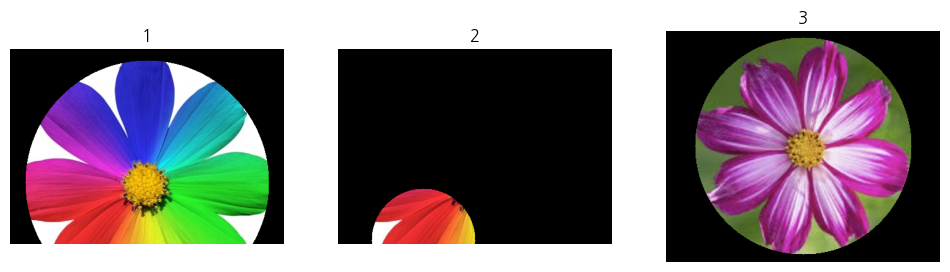

In [56]:
flower_r = cv2.imread('./Data/images/flower_rainbow.jpg')
flower_r = cv2.cvtColor(flower_r, cv2.COLOR_BGR2RGB)
flower = cv2.imread('./Data/images/flower.jpg')
flower = cv2.cvtColor(flower, cv2.COLOR_BGR2RGB)

mask_r = np.zeros_like(flower_r)
w,h = mask_r.shape[1], mask_r.shape[0]
cv2.circle(mask_r, (int(w/2), int(h/2)), 200, (255,255,255), -1)
masked_r = cv2.bitwise_and(flower_r, mask_r)

mask_rr = np.zeros_like(flower_r)
w,h = mask_rr.shape[1], mask_rr.shape[0]
cv2.circle(mask_rr, (int(w/3.2), int(h/1.4)), 85, (255,255,255), -1)
masked_rr = cv2.bitwise_and(flower_r, mask_rr)

mask_f = np.zeros_like(flower)
w,h = mask_f.shape[1], mask_f.shape[0]
cv2.circle(mask_f, (int(w/2), int(h/2)), 150, (255,255,255), -1)
masked_f = cv2.bitwise_and(flower, mask_f)

printPolts(1,3, [1,2,3], [masked_r, masked_rr, masked_f])

In [ ]:
# 1. flower.rainbow.jpg 이미지의 마스크 생성으로 꽃만 추출
flower_r = cv2.imread('./Data/images/flower_rainbow.jpg')
flower_r = cv2.cvtColor(flower_r, cv2.COLOR_BGR2HSV)





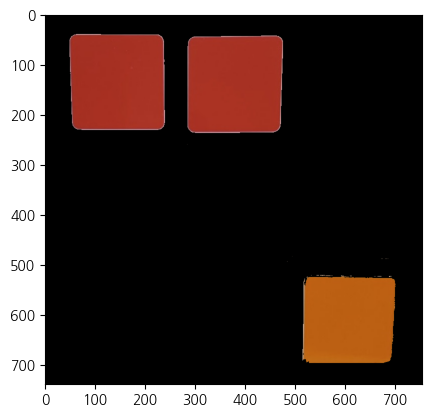

In [16]:
# 2. 빨강색 꽃잎만 추출
img = cv2.imread('./Data/images/cube.jpg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

red1 = np.array([0, 50, 50])
red2 = np.array([15, 255, 255])
red3 = np.array([165, 50, 50])
red4 = np.array([180, 255, 255])

mask_red1 = cv2.inRange(hsv, red1, red2)
mask_red2 = cv2.inRange(hsv, red3, red4)
res_red1 = cv2.bitwise_and(img, img, mask=mask_red1)
res_red2 = cv2.bitwise_and(img, img, mask=mask_red2)
res_red = cv2.bitwise_or(res_red1,res_red2)
res_red = cv2.cvtColor(res_red, cv2.COLOR_BGR2RGB)

plt.imshow(res_red)


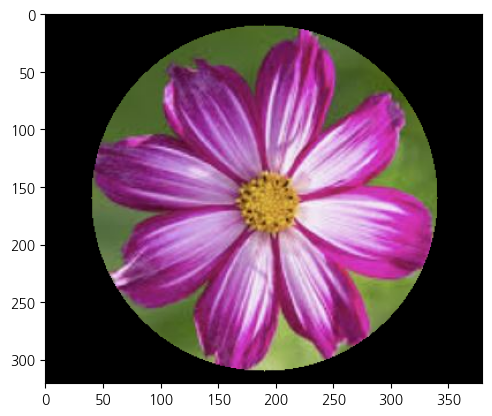

In [65]:
# 3. flower.jpg 꽃만 추출
flower = cv2.imread('./Data/images/flower.jpg')
flower = cv2.cvtColor(flower, cv2.COLOR_BGR2RGB)

mask = np.zeros_like(flower)

w,h = mask.shape[1], mask.shape[0]

cv2.circle(mask, (int(w/2), int(h/2)), 150, (255,255,255), -1)

masked = cv2.bitwise_and(flower, mask)


plt.imshow(masked)

In [ ]:
# 역투영 예제
win_name = 'back_projection'
img = cv2.imread('./Data/images/19752893c8538724f.jpg')
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
draw = img.copy()

def masking(bp, win_name):
    disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    cv2.filter2D(bp,-1,disc,bp)
    _, mask = cv2.threshold(bp, 1, 255, cv2.THRESH_BINARY)
    result = cv2.bitwise_and(img, img, mask=mask)
    cv2.imshow(win_name, result)

def backProject_manual(hist_roi):
    hist_img = cv2.calcHist([hsv_img], [0,1], None, [180,256], [0,180,0,256])
    hist_rate = hist_roi / (hist_img + 1)

    h, s, v = cv2.split(hsv_img)
    bp = hist_rate[h.ravel(), s.ravel()]
    bp = np.minimum(bp, 1)
    bp = bp.reshape(hsv_img.shape[:2])
    cv2.normalize(bp,bp, 0, 255, cv2.NORM_MINMAX)
    bp = bp.astype(np.uint8)
    masking(bp, 'result_manual')

def backProject_Cv(hist_roi):
    bp = cv2.calcBackProject([hsv_img], [0, 1], hist_roi, [0 , 180, 0, 256], 1)
    masking(bp,'result_cv')

(x,y,w,h) = cv2.selectROI(win_name, img, False)
if w > 0 and h > 0:
    roi = img[y:y+h, x:x+w]
    cv2.rectangle(draw, (x,y), (x+w, y+h), (0,0,255), 2)

    hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    hist_roi = cv2.calcHist([hsv_roi], [0,1], None, [180, 256], [0, 180, 0, 256])
    backProject_manual(hist_roi)
    backProject_Cv(hist_roi)

cv2.imshow(win_name, draw)
cv2.waitKey()
cv2.destroyAllWindows()

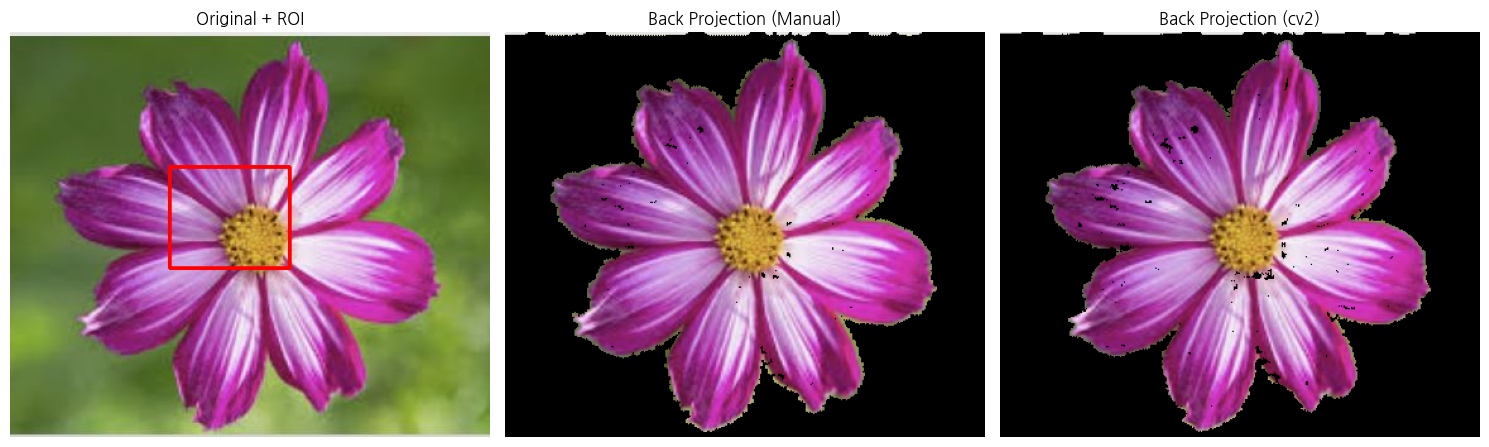

In [89]:
img = cv2.imread('./Data/images/flower.jpg')
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h_img, w_img = img.shape[:2]
x, y, w, h = w_img//3, h_img//3, w_img//4, h_img//4
roi = img[y:y+h, x:x+w]

hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
hist_roi = cv2.calcHist([hsv_roi], [0,1], None, [180,256], [0,180,0,256])

def get_mask(bp):
    disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    cv2.filter2D(bp, -1, disc, bp)
    _, mask = cv2.threshold(bp, 1, 255, cv2.THRESH_BINARY)
    return cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

def backProject_manual(hist_roi):
    hist_img = cv2.calcHist([hsv_img], [0,1], None, [180,256], [0,180,0,256])
    hist_rate = hist_roi / (hist_img + 1)
    h, s, v = cv2.split(hsv_img)
    bp = hist_rate[h.ravel(), s.ravel()]
    bp = np.minimum(bp, 1).reshape(hsv_img.shape[:2])
    cv2.normalize(bp, bp, 0, 255, cv2.NORM_MINMAX)
    return get_mask(bp.astype(np.uint8))

def backProject_cv(hist_roi):
    bp = cv2.calcBackProject([hsv_img], [0,1], hist_roi, [0,180,0,256], 1)
    return get_mask(bp)

result_manual = backProject_manual(hist_roi)
result_cv     = backProject_cv(hist_roi)

draw = img_rgb.copy()
cv2.rectangle(draw, (x,y), (x+w, y+h), (255,0,0), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(draw);          axes[0].set_title('Original + ROI')
axes[1].imshow(result_manual); axes[1].set_title('Back Projection (Manual)')
axes[2].imshow(result_cv);     axes[2].set_title('Back Projection (cv2)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()